# 🌩️ บทพิเศษ (Extras) — Vector Search ที่ Edge: Cloudflare Workers AI + Vectorize

**ภาคพิเศษ · Edge deployment** · grounded ใน `arra-oracle-v3/src/vector/adapters/cloudflare-vectorize.ts`

บท 1–15 รันในเครื่องเรา (local/Ollama) · บทนี้: เอาแนวคิดเดิม**ขึ้น edge ของ Cloudflare** (300+ เมืองทั่วโลก)
— embedding รันที่ Workers AI, เก็บเวกเตอร์ที่ Vectorize · โมเดลตัวเดิม (**bge-m3, 1024 มิติ**) แค่ย้ายที่รัน

> notebook นี้ **รันจริงได้ถ้ามี Cloudflare token** (ตั้ง env `CF_ACCOUNT_ID` + `CF_API_TOKEN`)
> ถ้าไม่มี → แสดง code path จริง + อธิบาย (ไม่ error) เพื่อให้เห็นว่าโค้ดหน้าตายังไง


In [1]:
import os, json, urllib.request
CF_ACCOUNT = os.environ.get('CF_ACCOUNT_ID')
CF_TOKEN = os.environ.get('CF_API_TOKEN')
HAS_CF = bool(CF_ACCOUNT and CF_TOKEN)
print('Cloudflare credentials:', '✓ พร้อมรันจริง' if HAS_CF else '— ไม่มี (จะแสดง code path + อธิบาย)')
print('ตั้งเองได้:  export CF_ACCOUNT_ID=xxx CF_API_TOKEN=xxx  (dashboard → My Profile → API Tokens)')


Cloudflare credentials: — ไม่มี (จะแสดง code path + อธิบาย)
ตั้งเองได้:  export CF_ACCOUNT_ID=xxx CF_API_TOKEN=xxx  (dashboard → My Profile → API Tokens)


## 1) Embedding ที่ edge — Workers AI (`@cf/baai/bge-m3`)

endpoint จริงจาก ARRA (`cloudflare-vectorize.ts` บรรทัด 53):
```
POST https://api.cloudflare.com/client/v4/accounts/{account}/ai/run/@cf/baai/bge-m3
```
**bge-m3 ตัวเดียวกับที่เราใช้ local** (บท 2/5) — แค่รันบน GPU ของ Cloudflare แทน Ollama ในเครื่อง


In [2]:
CF_MODEL = '@cf/baai/bge-m3'   # ตรงกับ CF_MODEL ใน cloudflare-vectorize.ts
CF_DIM = 1024

def cf_embed(texts):
    url = f'https://api.cloudflare.com/client/v4/accounts/{CF_ACCOUNT}/ai/run/{CF_MODEL}'
    req = urllib.request.Request(url,
        data=json.dumps({'text': texts}).encode(),
        headers={'Authorization': f'Bearer {CF_TOKEN}', 'Content-Type': 'application/json'})
    with urllib.request.urlopen(req, timeout=60) as r:
        return json.load(r)['result']['data']   # list ของเวกเตอร์ 1024 มิติ

if HAS_CF:
    v = cf_embed(['สวัสดี vector search ที่ edge'])
    print(f'Workers AI คืนเวกเตอร์ {len(v[0])} มิติ (คาดหวัง {CF_DIM}) ✓')
else:
    print('(ข้ามการเรียกจริง) โค้ดข้างบนคือ REST call ที่ ARRA ใช้ production — bge-m3 → 1024 มิติ')


(ข้ามการเรียกจริง) โค้ดข้างบนคือ REST call ที่ ARRA ใช้ production — bge-m3 → 1024 มิติ


## 2) เก็บ + ค้นเวกเตอร์ที่ edge — Vectorize (v2 REST)

endpoints จริง (`cloudflare-vectorize.ts` บรรทัด 211/248):
```
POST .../vectorize/v2/indexes/{index}/upsert   # NDJSON (1 เวกเตอร์/บรรทัด, batch ≤1000)
POST .../vectorize/v2/indexes/{index}/query    # {vector, topK, returnMetadata}
```
⚠️ index สร้างผ่าน **wrangler/dashboard** ไม่ใช่ runtime (comment จริงบรรทัด 149)


In [3]:
def cf_vectorize(path, body, ndjson=False):
    url = f'https://api.cloudflare.com/client/v4/accounts/{CF_ACCOUNT}/vectorize/v2/indexes/oracle-demo{path}'
    data = ('\n'.join(json.dumps(x) for x in body)).encode() if ndjson else json.dumps(body).encode()
    ct = 'application/x-ndjson' if ndjson else 'application/json'
    req = urllib.request.Request(url, data=data,
        headers={'Authorization': f'Bearer {CF_TOKEN}', 'Content-Type': ct})
    with urllib.request.urlopen(req, timeout=60) as r:
        return json.load(r)

# โครงสร้าง upsert (NDJSON): {id, values:[1024], metadata:{...}}
example_upsert = {'id': 'n1', 'values': '[...1024 floats...]', 'metadata': {'text': 'โน้ต', 'folder': 'teaching'}}
print('รูปแบบ 1 บรรทัด NDJSON ที่ Vectorize รับ:')
print(json.dumps(example_upsert, ensure_ascii=False)[:90], '...')


รูปแบบ 1 บรรทัด NDJSON ที่ Vectorize รับ:
{"id": "n1", "values": "[...1024 floats...]", "metadata": {"text": "โน้ต", "folder": "teac ...


## 3) local vs edge — เทียบให้เห็นภาพ


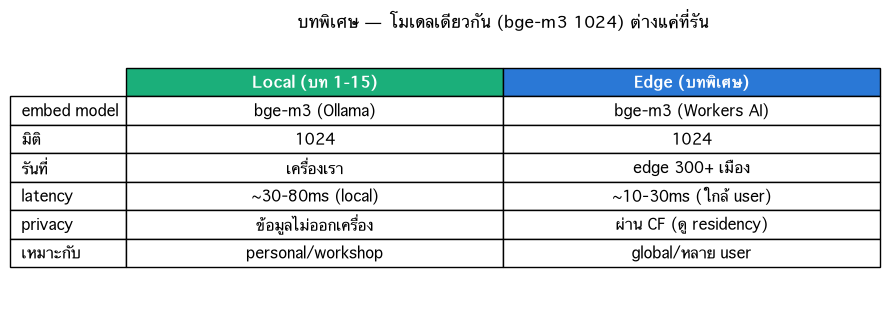

In [4]:
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
_av={f.name for f in _fm.fontManager.ttflist}
for _f in ['Thonburi','Loma','Sarabun','Noto Sans Thai']:
    if _f in _av: matplotlib.rcParams['font.family']=_f; break
matplotlib.rcParams['axes.unicode_minus']=False

rows = [
    ('embed model', 'bge-m3 (Ollama)', 'bge-m3 (Workers AI)'),
    ('มิติ', '1024', '1024'),
    ('รันที่', 'เครื่องเรา', 'edge 300+ เมือง'),
    ('latency', '~30-80ms (local)', '~10-30ms (ใกล้ user)'),
    ('privacy', 'ข้อมูลไม่ออกเครื่อง', 'ผ่าน CF (ดู residency)'),
    ('เหมาะกับ', 'personal/workshop', 'global/หลาย user'),
]
fig, ax = plt.subplots(figsize=(9, 3.2)); ax.axis('off')
tbl = ax.table(cellText=[[r[1], r[2]] for r in rows], rowLabels=[r[0] for r in rows],
               colLabels=['Local (บท 1-15)', 'Edge (บทพิเศษ)'], cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.6)
for j,cl in [(0,'#1baf7a'),(1,'#2a78d6')]:
    tbl[0,j].set_facecolor(cl); tbl[0,j].set_text_props(color='white', fontweight='bold')
plt.title('บทพิเศษ — โมเดลเดียวกัน (bge-m3 1024) ต่างแค่ที่รัน'); plt.tight_layout(); plt.show()


## ✅ วัดผลตัวเอง (บทพิเศษ)


In [5]:
# concept ต้องตรง: CF ใช้ bge-m3 1024 มิติ เท่ากับ local (ความรู้ติดตัว)
assert CF_MODEL == '@cf/baai/bge-m3' and CF_DIM == 1024, 'CF ใช้ bge-m3 1024 มิติ (ตรงกับ local)'
if HAS_CF:
    v = cf_embed(['ทดสอบ'])
    assert len(v[0]) == CF_DIM, f'Workers AI ต้องคืน {CF_DIM} มิติ'
    print('✅ ผ่าน (รันจริงกับ Cloudflare)! edge embedding = 1024 มิติ เท่า local')
else:
    print('✅ ผ่าน (concept)! โมเดล/มิติ/endpoint ตรงกับ ARRA production · ตั้ง CF token เพื่อรันจริง')
print('→ ความรู้ทั้ง 15 บท (cosine/hybrid/RAG/threshold) ใช้ได้เหมือนกันบน edge — เปลี่ยนแค่ transport')


✅ ผ่าน (concept)! โมเดล/มิติ/endpoint ตรงกับ ARRA production · ตั้ง CF token เพื่อรันจริง
→ ความรู้ทั้ง 15 บท (cosine/hybrid/RAG/threshold) ใช้ได้เหมือนกันบน edge — เปลี่ยนแค่ transport


## 🎓 สรุปบทพิเศษ

| | Local (บท 1–15) | Edge (บทนี้) |
|---|---|---|
| embed | Ollama bge-m3 | Workers AI `@cf/baai/bge-m3` |
| store | Chroma/LanceDB | Vectorize v2 |
| ค้น | ในเครื่อง | ใกล้ user (300+ เมือง) |
| เมื่อไหร่ | personal/workshop | global/หลาย user |

**หัวใจ:** โมเดล + สมการ + hybrid + threshold เหมือนกันทุกอย่าง — edge เปลี่ยนแค่ *ที่รัน* กับ *transport*
ความรู้ทั้งเล่มจึง **portable** ข้าม local↔edge (เหมือน Chroma↔LanceDB ในบท 10)

*grounded: arra-oracle-v3 cloudflare-vectorize.ts · deep-technical Ch5 (Workers AI), Ch14 (Vectorize/D1), Ch69 (edge/residency)*
